<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Hackaton_03_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

# Neural Networks: Basics



In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
#@title GT functions

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def sample_curve_params(K, amp_range=(0.5, 1.5), sigma_range=(0.03, 0.12), baseline_range=(-0.2, 0.2)):
    mus = np.sort(np.random.uniform(0.05, 0.95, size=K))
    amps = np.random.uniform(*amp_range, size=K)
    sigs = np.random.uniform(*sigma_range, size=K)
    b = np.random.uniform(*baseline_range)
    return amps, mus, sigs, b

def curve_function(x, amps, mus, sigs, b):
    y = np.zeros_like(x) + b
    for a, m, s in zip(amps, mus, sigs):
        y += a * gaussian(x, m, s)
    return y

class PeakCurveOptDataset(Dataset):
    """
    X: noisy curve samples on a fixed grid (n_points,)
    y: true optimum value (max of noise-free curve), scalar
    Also returns y_true_curve if you want to visualize.
    """
    def __init__(self, K, n_curves=2000, n_points=128, noise_std=0.05, grid_n=1024):
        self.K = K
        self.n_curves = n_curves
        self.n_points = n_points
        self.noise_std = noise_std

        # fixed measurement grid (what the student "measures")
        self.x_meas = np.linspace(0, 1, n_points).astype(np.float32)

        # dense grid to compute "true optimum" accurately
        self.x_dense = np.linspace(0, 1, grid_n).astype(np.float32)

        X = np.zeros((n_curves, n_points), dtype=np.float32)
        y_opt = np.zeros((n_curves, 1), dtype=np.float32)   # scalar target
        Y_true = np.zeros((n_curves, n_points), dtype=np.float32)

        for i in range(n_curves):
            amps, mus, sigs, b = sample_curve_params(K)

            y_dense = curve_function(self.x_dense, amps, mus, sigs, b).astype(np.float32)
            y_opt[i, 0] = y_dense.max()     # <-- "true optimum value"

            y_true = curve_function(self.x_meas, amps, mus, sigs, b).astype(np.float32)
            y_noisy = y_true + np.random.normal(0.0, noise_std, size=n_points).astype(np.float32)

            X[i] = y_noisy
            Y_true[i] = y_true

        self.X = X
        self.y = y_opt
        self.Y_true = Y_true

        # optional normalization (usually helps)
        self.X_mean = self.X.mean()
        self.X_std = self.X.std() + 1e-8
        self.Xn = (self.X - self.X_mean) / self.X_std

    def __len__(self):
        return self.n_curves

    def __getitem__(self, idx):
        # return normalized curve as (n_points,), and scalar target as (1,)
        return torch.from_numpy(self.Xn[idx]), torch.from_numpy(self.y[idx])

In [3]:
#dataset generation K - number of peaks; noise_std - noise level

dataset = PeakCurveOptDataset(
    K = 1,
    noise_std=.1,

    )

dataset.X.shape, dataset.Y_true.shape

((2000, 128), (2000, 128))

Text(0.5, 0, 'x')

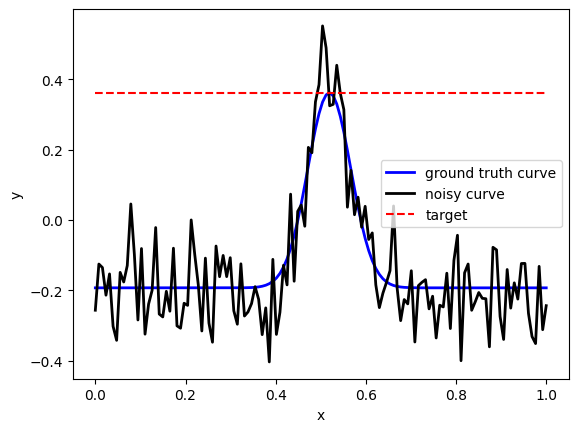

In [4]:
#curve example
ii=1

plt.plot(dataset.x_meas,dataset.Y_true[ii].flatten(), label = 'ground truth curve', c='blue', lw=2)
plt.plot(dataset.x_meas, dataset.X[ii].flatten(), label = 'noisy curve', c='k', lw=2)

plt.hlines(dataset.y[ii], 0, 1, linestyle = '--', color='r', label= 'target')
plt.legend(loc='center right')

plt.ylabel('y')
plt.xlabel('x')

You are given a generator that produces:

 - detaset.X: noisy sampled curves (vector of length n_points)

 - detaset.y: true maximum value of the underlying noise-free curve

The curves consist of K Gaussian peaks, where $K ∈ [1,2,3,4]$.

Your goal is to build a neural network to predict maximum value by the noise spectran and study how performance depends on:

- Number of peaks ($K$) → data complexity
- Noise level ($σ$)
- Network architecture → depth and width

# Tasks
**1) Build a Model**

Create a neural network that predicts the true maximum from the noisy input spectrum. (You may use an LLM to help sketch the architecture.)

** 2) Evaluate **

Test it on the separate test dataset

**3) Capacity Study (fixed K and noise)**

  - Vary number of hidden layers
  - Vary number of neurons per layer

Find the architecture with the lowest test MSE.
Analyse the results.

**4) Noise Study (fixed K)**

Vary noise level. How does noise affect:

 - Best achievable MSE?
 - Optimal model size?

**5) Complexity study**

Perform the similar analysis for the different K = 1, 2, 3, 4...

How does required capacity change with increasing number of peaks?


**For each condition report:**
 - Best architecture (depth, width)
 - Test MSE

**Final discussion (3–5 bullet points):**
 - Effect of K (data complexity)
 - Effect of noise
 - Effect of model size

**Submission deadline: 10:05 AM — send notebook to Sergei.**


In [5]:
import itertools

# ---- Model ----
class MLPRegressor(nn.Module):
    def __init__(self, input_dim=128, depth=2, width=64):
        super().__init__()
        layers = []
        d = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, width))
            layers.append(nn.ReLU())
            d = width
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def make_loaders(K, noise_std, n_train=1500, n_test=400, batch_size=128, seed=0):
    set_seed(seed)
    train_ds = PeakCurveOptDataset(K=K, n_curves=n_train, noise_std=noise_std)
    set_seed(seed + 1)
    test_ds = PeakCurveOptDataset(K=K, n_curves=n_test, noise_std=noise_std)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def collect_predictions(model, loader, device):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().reshape(-1)
            y = yb.cpu().numpy().reshape(-1)
            preds.append(pred)
            trues.append(y)
    return np.concatenate(preds), np.concatenate(trues)


def show_prediction_examples(model, loader, device, n_show=10, title="Sample predictions"):
    preds, trues = collect_predictions(model, loader, device)
    n_show = min(n_show, len(preds))

    print(f"\n{title}")
    print("-" * len(title))
    print("idx	true	pred	abs_err")
    for i in range(n_show):
        err = abs(preds[i] - trues[i])
        print(f"{i:02d}	{trues[i]:.5f}	{preds[i]:.5f}	{err:.5f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].scatter(trues, preds, s=12, alpha=0.65)
    lo = min(trues.min(), preds.min())
    hi = max(trues.max(), preds.max())
    ax[0].plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax[0].set_xlabel('True max value')
    ax[0].set_ylabel('Predicted max value')
    ax[0].set_title('Predictions vs True (test set)')
    ax[0].grid(alpha=0.3)

    idx = np.arange(n_show)
    ax[1].plot(idx, trues[:n_show], marker='o', label='True')
    ax[1].plot(idx, preds[:n_show], marker='x', label='Pred')
    ax[1].set_xlabel('Example index')
    ax[1].set_ylabel('Max value')
    ax[1].set_title(f'First {n_show} test examples')
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_mse(model, loader, device):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            total += torch.sum((pred - yb) ** 2).item()
            n += yb.shape[0]
    return total / max(n, 1)


def train_and_test_mse(K, noise_std, depth, width, epochs=12, lr=1e-3, seed=0, return_model=False):
    train_loader, test_loader = make_loaders(K=K, noise_std=noise_std, seed=seed)

    model = MLPRegressor(input_dim=128, depth=depth, width=width).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

    test_mse = evaluate_mse(model, test_loader, device)
    if return_model:
        return test_mse, model, test_loader
    return test_mse


def run_grid(K, noise_std, depths, widths, epochs=12, seed=0):
    rows = []
    for depth, width in itertools.product(depths, widths):
        mse = train_and_test_mse(
            K=K,
            noise_std=noise_std,
            depth=depth,
            width=width,
            epochs=epochs,
            seed=seed,
        )
        rows.append({"K": K, "noise": noise_std, "depth": depth, "width": width, "test_mse": mse})
    rows = sorted(rows, key=lambda r: r["test_mse"])
    return rows


def print_top(rows, top_k=5, title="Top results"):
    print(f"\n{title}")
    print("-" * len(title))
    for r in rows[:top_k]:
        print(
            f"depth={r['depth']:<2d} width={r['width']:<3d} "
            f"K={r['K']} noise={r['noise']:.2f} test_mse={r['test_mse']:.6f}"
        )




Capacity study (K=2, noise=0.1)
-------------------------------
depth=3  width=128 K=2 noise=0.10 test_mse=0.018875
depth=2  width=128 K=2 noise=0.10 test_mse=0.019374
depth=3  width=64  K=2 noise=0.10 test_mse=0.024258
depth=2  width=64  K=2 noise=0.10 test_mse=0.028216
depth=1  width=128 K=2 noise=0.10 test_mse=0.030670
depth=1  width=32  K=2 noise=0.10 test_mse=0.034991
depth=2  width=32  K=2 noise=0.10 test_mse=0.035590
depth=1  width=64  K=2 noise=0.10 test_mse=0.035955
depth=3  width=32  K=2 noise=0.10 test_mse=0.043404

Best architecture @ K=2, noise=0.1: depth=3, width=128, test_mse=0.018875
Verification run MSE (best architecture): 0.018875

Best model predictions
----------------------
idx	true	pred	abs_err
00	1.16436	1.31312	0.14876
01	1.26703	0.99443	0.27260
02	1.26962	1.14474	0.12488
03	1.69459	1.71322	0.01862
04	1.58784	1.64187	0.05403
05	1.43202	1.54925	0.11723
06	1.20863	1.21134	0.00271
07	1.58723	1.52328	0.06395
08	0.83770	0.89588	0.05819
09	0.54043	0.61423	0.07380
10

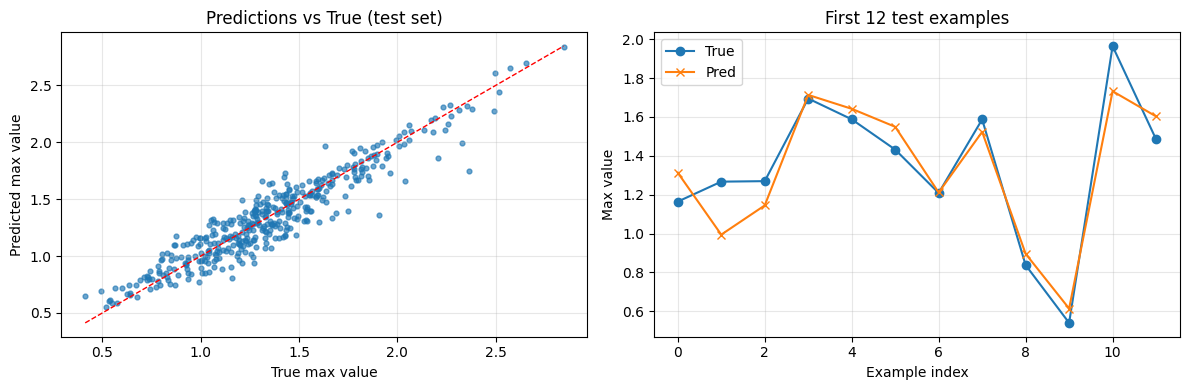

In [6]:

# =========================
# 1) Build + 2) Evaluate + 3) Capacity Study
# =========================
depths = [1, 2, 3]
widths = [32, 64, 128]

K_fixed = 2
noise_fixed = 0.10

capacity_rows = run_grid(K=K_fixed, noise_std=noise_fixed, depths=depths, widths=widths, epochs=12, seed=10)
print_top(capacity_rows, top_k=9, title=f"Capacity study (K={K_fixed}, noise={noise_fixed})")

best_capacity = capacity_rows[0]
print(
    f"\nBest architecture @ K={K_fixed}, noise={noise_fixed}: "
    f"depth={best_capacity['depth']}, width={best_capacity['width']}, "
    f"test_mse={best_capacity['test_mse']:.6f}"
)

best_mse, best_model, best_test_loader = train_and_test_mse(
    K=K_fixed,
    noise_std=noise_fixed,
    depth=best_capacity['depth'],
    width=best_capacity['width'],
    epochs=12,
    seed=10,
    return_model=True,
)

print(f"Verification run MSE (best architecture): {best_mse:.6f}")
show_prediction_examples(best_model, best_test_loader, device, n_show=12, title="Best model predictions")




In [7]:

# =========================
# 4) Noise study (fixed K)
# =========================
noise_levels = [0.02, 0.05, 0.10, 0.15, 0.20]
noise_best = []

for nstd in noise_levels:
    rows = run_grid(K=K_fixed, noise_std=nstd, depths=depths, widths=widths, epochs=10, seed=20)
    noise_best.append(rows[0])

print("\nNoise study (best architecture per noise)")
print("----------------------------------------")
for r in noise_best:
    print(
        f"noise={r['noise']:.2f} -> depth={r['depth']}, width={r['width']}, "
        f"test_mse={r['test_mse']:.6f}"
    )




Noise study (best architecture per noise)
----------------------------------------
noise=0.02 -> depth=2, width=128, test_mse=0.018316
noise=0.05 -> depth=2, width=128, test_mse=0.019049
noise=0.10 -> depth=2, width=128, test_mse=0.021327
noise=0.15 -> depth=2, width=128, test_mse=0.024495
noise=0.20 -> depth=3, width=128, test_mse=0.028436


In [8]:

# =========================
# 5) Complexity study (K)
# =========================
K_values = [1, 2, 3, 4]
complexity_best = []

for K in K_values:
    rows = run_grid(K=K, noise_std=noise_fixed, depths=depths, widths=widths, epochs=10, seed=30)
    complexity_best.append(rows[0])

print("\nComplexity study (best architecture per K)")
print("-------------------------------------------")
for r in complexity_best:
    print(
        f"K={r['K']} -> depth={r['depth']}, width={r['width']}, "
        f"test_mse={r['test_mse']:.6f}"
    )




Complexity study (best architecture per K)
-------------------------------------------
K=1 -> depth=3, width=128, test_mse=0.004059
K=2 -> depth=3, width=128, test_mse=0.021133
K=3 -> depth=3, width=128, test_mse=0.035313
K=4 -> depth=3, width=128, test_mse=0.045681


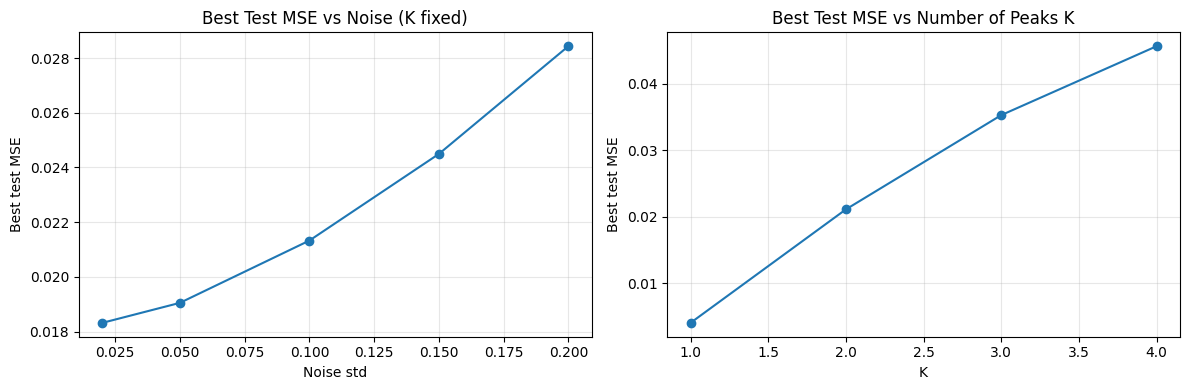

In [9]:

# =========================
# Visualization
# =========================
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot([r["noise"] for r in noise_best], [r["test_mse"] for r in noise_best], marker="o")
ax[0].set_title("Best Test MSE vs Noise (K fixed)")
ax[0].set_xlabel("Noise std")
ax[0].set_ylabel("Best test MSE")
ax[0].grid(alpha=0.3)

ax[1].plot([r["K"] for r in complexity_best], [r["test_mse"] for r in complexity_best], marker="o")
ax[1].set_title("Best Test MSE vs Number of Peaks K")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Best test MSE")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()




In [12]:
noise_mses = [r["test_mse"] for r in noise_best]
k_mses = [r["test_mse"] for r in complexity_best]

print("----------------")
print(f"- Noise effect: best test MSE changes from {noise_mses[0]:.6f} (low noise) to {noise_mses[-1]:.6f} (high noise).")
print(f"- Complexity effect: best test MSE for K=1 is {k_mses[0]:.6f}, and for K=4 is {k_mses[-1]:.6f}.")

----------------
- Noise effect: best test MSE changes from 0.018316 (low noise) to 0.028436 (high noise).
- Complexity effect: best test MSE for K=1 is 0.004059, and for K=4 is 0.045681.


## Final Discussion

- **Effect of K (data complexity):**  
  As the number of peaks $K$ increases, the test MSE increases significantly. This indicates that the function becomes more complex and harder for the neural network to approximate. Higher $K$ therefore requires greater model capacity or more training data.

- **Effect of noise:**  
  Increasing the noise level steadily increases test MSE. Noise introduces uncertainty in the data, limiting how accurately the underlying signal can be learned even with larger models.

- **Effect of model size:**  
  Larger models (greater depth and width) generally achieve lower test MSE. In this experiments, the best performance was obtained with **depth = 3 and width = 128**, showing that higher capacity networks are better able to capture the structure of the data.
